# ImageNet-64 FID trajectories

Discover every `imagenet64_*` run, evaluate checkpoints at **10,000-step intervals**, cache each FID result, and plot trajectories across runs.

The expensive sweep is restartable: `evaluate_checkpoint_fidutil.py --skip-existing` validates and reuses completed JSON files. By default the notebook evaluates a fixed CFG scale of 2.0, which makes values comparable across checkpoints. Set `CFG_SCALES = ""` below to evaluate every scale from each training config (much more expensive).

Run the cells from top to bottom. The evaluation cell invokes one checkpoint at a time and continues after failures; rerun it to retry missing/failed items.

In [1]:
from __future__ import annotations

import json
import math
import os
import re
import shutil
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import display

# Locate the repository even if Jupyter starts in notebooks/.
here = Path.cwd().resolve()
REPO = next((p for p in (here, *here.parents) if (p / "evaluate_checkpoint_fidutil.py").is_file()), None)
if REPO is None:
    raise FileNotFoundError("Start Jupyter inside the riesz_flow_hudson repository")

RDS_ROOT = Path("/home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM")
RUNS_ROOT = RDS_ROOT / "runs"
RESULTS_ROOT = RDS_ROOT / "artifacts" / "fid_imagenet64"
NODE_TMP = Path(os.environ.get("SLURM_TMPDIR") or os.environ.get("TMPDIR") or "/tmp")
TMP_ROOT = NODE_TMP / f"fid_imagenet64_{os.environ.get('SLURM_JOB_ID', os.getpid())}"
STEP_INTERVAL = 10_000
NUM_SAMPLES = 50_000       # Standard reportable FID-50K
CFG_SCALES = "2.0"       # blank => every scale listed in the config
GEN_BSZ_PER_GPU = 64
NPROC_PER_NODE = 1         # Dawn interactive oneCCL is unreliable with two local ranks
SEED = 0
FID_REF = ""             # blank => utils.env.IMAGENET64_FID_NPZ
RUN_NAME_REGEX = r"^imagenet64_"
MAX_CHECKPOINTS = None      # e.g. 2 for a smoke test; None evaluates everything

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
TMP_ROOT.mkdir(parents=True, exist_ok=True)
tmp_free_gib = shutil.disk_usage(TMP_ROOT).free / 1024**3
if tmp_free_gib < 5:
    raise RuntimeError(f"Node-local scratch has only {tmp_free_gib:.1f} GiB free: {TMP_ROOT}")
print(f"Repository: {REPO}")
print(f"Runs:       {RUNS_ROOT}")
print(f"Results:    {RESULTS_ROOT}")
print(f"Temporary:  {TMP_ROOT} ({tmp_free_gib:.1f} GiB free)")

Repository: /home/rc-chen1/riesz_flow_hudson
Runs:       /home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/runs
Results:    /home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/artifacts/fid_imagenet64
Temporary:  /tmp/fid_imagenet64_33528868 (16.0 GiB free)


## Map runs to training configs

Model construction must use a config with the checkpoint's original model architecture. The ordered rules below cover the current run names (including the 384-wide Mingyuan/RMS families). If a newly discovered run is unresolved, add a more-specific rule before the generic ones. The inventory cell refuses to evaluate unresolved runs.

In [2]:
CONFIG_RULES = [
    (r"matern32.*(?:rms|frozen_velocity).*lr4e4", "configs/gen/imagenet64_matern32_rms_lr4e4.yaml"),
    (r"direct_riesz_no_support_const_lr", "configs/gen/imagenet64_direct_riesz_no_support_const_lr.yaml"),
    (r"drifting_150k_mingyuan_const", "configs/gen/imagenet64_drifting_150k_mingyuan_const.yaml"),
    (r"sinkhorn_150k_mingyuan_const", "configs/gen/imagenet64_sinkhorn_150k_mingyuan_const.yaml"),
    (r"sinkhorn_150k_mingyuan", "configs/gen/imagenet64_sinkhorn_150k_mingyuan.yaml"),
    (r"sliced_riesz.*rms_lr4e4", "configs/gen/imagenet64_sliced_riesz_rms_lr4e4.yaml"),
    (r"sliced_riesz.*(?:mingyuan|frozen_velocity_rms)", "configs/gen/imagenet64_sliced_riesz_rms_lr4e4.yaml"),
    (r"sliced_riesz", "configs/gen/imagenet64_sliced_riesz.yaml"),
    (r"riesz.*rms_lr4e4", "configs/gen/imagenet64_riesz_rms_lr4e4.yaml"),
    (r"riesz.*frozen_velocity_rms", "configs/gen/imagenet64_riesz_rms_lr4e4.yaml"),
    (r"riesz.*mingyuan_const", "configs/gen/imagenet64_riesz_150k_mingyuan.yaml"),
    (r"riesz", "configs/gen/imagenet64_riesz.yaml"),
]

STEP_RE = re.compile(r"^state_(\d+)\.pt$")

def config_for_run(run_name: str) -> Path | None:
    for pattern, relative_path in CONFIG_RULES:
        if re.search(pattern, run_name):
            return (REPO / relative_path).resolve()
    return None

def discover_inventory() -> pd.DataFrame:
    rows = []
    for run_dir in sorted(RUNS_ROOT.iterdir()):
        if not run_dir.is_dir() or re.search(RUN_NAME_REGEX, run_dir.name) is None:
            continue
        config = config_for_run(run_dir.name)
        for checkpoint in sorted((run_dir / "checkpoints").glob("state_*.pt")):
            match = STEP_RE.match(checkpoint.name)
            if match is None:
                continue
            step = int(match.group(1))
            if step > 0 and step % STEP_INTERVAL == 0:
                rows.append({
                    "run": run_dir.name,
                    "step": step,
                    "checkpoint": checkpoint.resolve(),
                    "config": config,
                })
    return pd.DataFrame(rows).sort_values(["run", "step"]).reset_index(drop=True)

inventory = discover_inventory()
if inventory.empty:
    raise RuntimeError(f"No checkpoints divisible by {STEP_INTERVAL:,} found under {RUNS_ROOT}")

bad_configs = inventory[inventory["config"].map(lambda p: p is None or not p.is_file())]
summary = inventory.groupby("run").agg(checkpoints=("step", "size"), first_step=("step", "min"), last_step=("step", "max"), config=("config", lambda values: values.iloc[0].name if values.iloc[0] is not None else "<unmapped>"))
display(summary)
print(f"{len(inventory)} checkpoints across {inventory['run'].nunique()} runs")
if not bad_configs.empty:
    display(bad_configs[["run", "config"]].drop_duplicates())
    raise RuntimeError("Resolve the config mappings above before evaluation")

# Guard against accidentally loading an ImageNet-256 config.
for config_path in inventory["config"].drop_duplicates():
    config_data = yaml.safe_load(config_path.read_text())
    assert int(config_data["dataset"]["resolution"]) == 64, config_path

,checkpoints,first_step,last_step,config
run,,,,
imagenet64_direct_riesz_no_support_const_lr_ps_1,5,10000,50000,imagenet64_direct_riesz_no_support_const_lr.yaml
imagenet64_drifting_150k_mingyuan_const_ps_1,3,10000,30000,imagenet64_drifting_150k_mingyuan_const.yaml
imagenet64_matern32_frozen_velocity_rms_multiscale_lr4e4_ps_1,2,10000,20000,imagenet64_matern32_rms_lr4e4.yaml
imagenet64_riesz_fresh_support_mingyuan_const_ps_1,5,10000,50000,imagenet64_riesz_150k_mingyuan.yaml
imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1,13,10000,130000,imagenet64_riesz_rms_lr4e4.yaml
imagenet64_riesz_frozen_velocity_rms_ps_1,7,10000,70000,imagenet64_riesz_rms_lr4e4.yaml
imagenet64_sinkhorn_150k_mingyuan_const_ps_1,3,10000,30000,imagenet64_sinkhorn_150k_mingyuan_const.yaml
imagenet64_sliced_riesz_fresh_support_lr4e4_mingyuan_const_ps_1,4,10000,40000,imagenet64_sliced_riesz_rms_lr4e4.yaml
imagenet64_sliced_riesz_fresh_support_mingyuan_const_ps_1,9,10000,90000,imagenet64_sliced_riesz_rms_lr4e4.yaml


71 checkpoints across 12 runs


## Evaluate all selected checkpoints

This is the expensive cell. Before launching an evaluator, it validates the requested cached JSON files and skips checkpoints that are already complete. The evaluator also receives `--skip-existing` as a second safety check. It streams output and writes a status manifest after every attempted evaluation. For a quick pipeline check, first set `NUM_SAMPLES = 1000` and `MAX_CHECKPOINTS = 1`; restore 50,000 for reportable FID.


In [3]:
manifest_path = RESULTS_ROOT / "evaluation_manifest.jsonl"
items = inventory.head(MAX_CHECKPOINTS) if MAX_CHECKPOINTS else inventory
log_dir = RESULTS_ROOT / "logs"
log_dir.mkdir(parents=True, exist_ok=True)


def valid_cached_result(path: Path, row, cfg_scale: float) -> bool:
    """Return True only for a complete result matching this exact evaluation."""
    try:
        payload = json.loads(path.read_text())
        return (
            int(payload["step"]) == int(row["step"])
            and float(payload["cfg_scale"]) == float(cfg_scale)
            and int(payload["num_samples"]) == NUM_SAMPLES
            and Path(payload["ckpt"]).resolve() == Path(row["checkpoint"]).resolve()
            and math.isfinite(float(payload["fid"]))
            and (not FID_REF.strip() or Path(payload["fid_ref"]).resolve() == Path(FID_REF).expanduser().resolve())
        )
    except (OSError, KeyError, TypeError, ValueError, json.JSONDecodeError):
        return False


requested_cfgs = [float(value) for value in CFG_SCALES.replace(",", " ").split()] if CFG_SCALES.strip() else None

for position, (_, row) in enumerate(items.iterrows(), start=1):
    run_result_dir = RESULTS_ROOT / row["run"]

    # Avoid even launching the evaluator (and loading the model) when every
    # explicitly requested CFG result is already complete and valid.
    if requested_cfgs is not None:
        cached_paths = [
            run_result_dir / f"fid{NUM_SAMPLES // 1000}k_step{int(row['step']):08d}_cfg{cfg:g}.json"
            for cfg in requested_cfgs
        ]
        if all(valid_cached_result(path, row, cfg) for path, cfg in zip(cached_paths, requested_cfgs)):
            print(f"\n[{position}/{len(items)}] SKIP cached: {row['run']} @ {row['step']:,}", flush=True)
            continue

    command = [
        sys.executable, "-m", "torch.distributed.run",
        f"--nproc_per_node={NPROC_PER_NODE}",
        str(REPO / "evaluate_checkpoint_fidutil.py"),
        "--run-dir", str(RUNS_ROOT / row["run"]),
        "--ckpt", str(row["checkpoint"]),
        "--config", str(row["config"]),
        "--num-samples", str(NUM_SAMPLES),
        "--gen-bsz", str(GEN_BSZ_PER_GPU),
        "--seed", str(SEED),
        "--result-dir", str(run_result_dir),
        "--work-root", str(TMP_ROOT / row["run"]),
        "--skip-existing",
    ]
    if CFG_SCALES.strip():
        command += ["--cfg-scales", CFG_SCALES]
    if FID_REF.strip():
        command += ["--fid-ref", FID_REF]

    print(f"\n[{position}/{len(items)}] {row['run']} @ {row['step']:,}", flush=True)
    started = datetime.now(timezone.utc).isoformat()
    log_path = log_dir / f"{row['run']}_step{int(row['step']):08d}.log"
    with log_path.open("w", encoding="utf-8") as log_handle:
        subprocess_env = os.environ.copy()
        subprocess_env.update({"TMPDIR": str(TMP_ROOT), "TEMP": str(TMP_ROOT), "TMP": str(TMP_ROOT)})
        completed = subprocess.run(
            command, cwd=REPO, env=subprocess_env, check=False, stdout=log_handle, stderr=subprocess.STDOUT
        )
    record = {
        "timestamp_utc": started,
        "run": row["run"],
        "step": int(row["step"]),
        "checkpoint": str(row["checkpoint"]),
        "returncode": completed.returncode,
    }
    with manifest_path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(record) + "\n")
    if completed.returncode:
        print(f"FAILED (recorded; see {log_path})", flush=True)

print(f"Finished sweep. Status log: {manifest_path}")



[1/71] SKIP cached: imagenet64_direct_riesz_no_support_const_lr_ps_1 @ 10,000



[2/71] SKIP cached: imagenet64_direct_riesz_no_support_const_lr_ps_1 @ 20,000



[3/71] SKIP cached: imagenet64_direct_riesz_no_support_const_lr_ps_1 @ 30,000



[4/71] SKIP cached: imagenet64_direct_riesz_no_support_const_lr_ps_1 @ 40,000



[5/71] SKIP cached: imagenet64_direct_riesz_no_support_const_lr_ps_1 @ 50,000


...


[68/71] imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1 @ 40,000



[69/71] imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1 @ 50,000



[70/71] imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1 @ 60,000



[71/71] imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1 @ 70,000


Finished sweep. Status log: /home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/artifacts/fid_imagenet64/evaluation_manifest.jsonl


## Final visualization: all FID trajectories

Each point corresponds to one run, checkpoint, and CFG scale. This final cell prints every trajectory, writes the combined data to CSV, reports missing 10,000-step evaluations, and saves one plot containing all available trajectories. If multiple CFG scales were evaluated, it also saves a best-of-CFG plot.


FID trajectory (lower is better):
                                                            run   step  cfg_scale       fid
               imagenet64_direct_riesz_no_support_const_lr_ps_1  10000        2.0 41.536550
               imagenet64_direct_riesz_no_support_const_lr_ps_1  20000        2.0 36.112371
               imagenet64_direct_riesz_no_support_const_lr_ps_1  30000        2.0 33.985062
               imagenet64_direct_riesz_no_support_const_lr_ps_1  40000        2.0 33.058271
               imagenet64_direct_riesz_no_support_const_lr_ps_1  50000        2.0 32.494918
                   imagenet64_drifting_150k_mingyuan_const_ps_1  10000        2.0 42.037488
                   imagenet64_drifting_150k_mingyuan_const_ps_1  20000        2.0 36.687513
                   imagenet64_drifting_150k_mingyuan_const_ps_1  30000        2.0 34.627170
  imagenet64_matern32_frozen_velocity_rms_multiscale_lr4e4_ps_1  10000        2.0 40.471730
  imagenet64_matern32_frozen_velocity_rms_mult

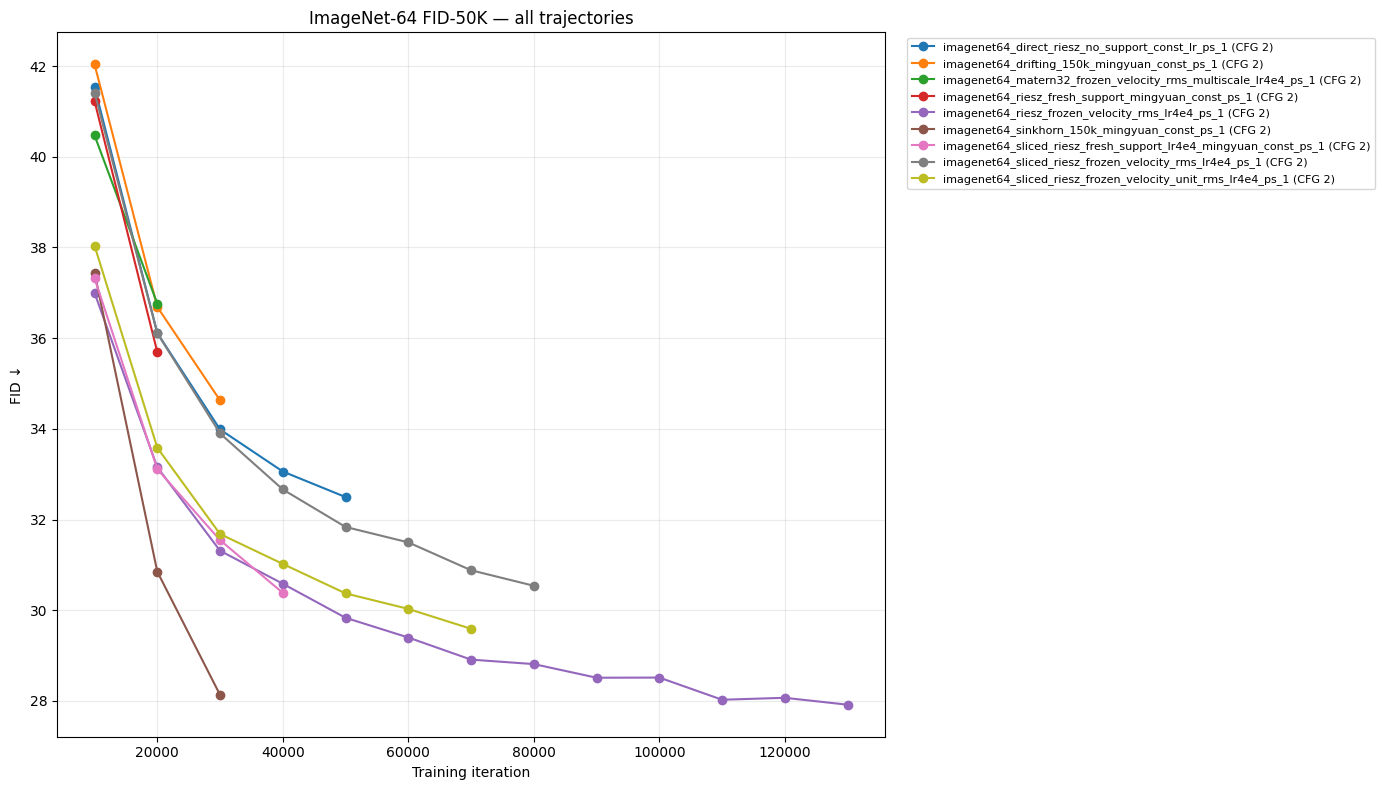

Saved /home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/artifacts/fid_imagenet64/fid50k_trajectory.png


In [4]:
def load_fid_results() -> pd.DataFrame:
    rows = []
    pattern = f"fid{NUM_SAMPLES // 1000}k_step*_cfg*.json"
    for path in RESULTS_ROOT.rglob(pattern):
        try:
            payload = json.loads(path.read_text())
            fid = float(payload["fid"])
            if not math.isfinite(fid):
                raise ValueError(f"non-finite FID: {fid}")
            rows.append({
                "run": Path(payload["ckpt"]).expanduser().resolve().parent.parent.name,
                "step": int(payload["step"]),
                "cfg_scale": float(payload["cfg_scale"]),
                "fid": fid,
                "num_samples": int(payload["num_samples"]),
                "result": path,
            })
        except (OSError, KeyError, TypeError, ValueError, json.JSONDecodeError) as exc:
            print(f"Ignoring invalid result {path}: {exc}")
    if not rows:
        return pd.DataFrame(columns=["run", "step", "cfg_scale", "fid", "num_samples", "result"])
    frame = pd.DataFrame(rows).sort_values(["run", "cfg_scale", "step"]).reset_index(drop=True)
    duplicates = frame.duplicated(["run", "step", "cfg_scale"], keep=False)
    if duplicates.any():
        raise RuntimeError(f"Duplicate FID results:\n{frame.loc[duplicates]}")
    return frame

results = load_fid_results()
if results.empty:
    print("No matching cached results yet. Run the evaluation cell above.")
else:
    trajectory = results[["run", "step", "cfg_scale", "fid"]].copy()
    trajectory_path = RESULTS_ROOT / f"fid{NUM_SAMPLES // 1000}k_trajectory.csv"
    trajectory.to_csv(trajectory_path, index=False)
    print("FID trajectory (lower is better):")
    print(trajectory.to_string(index=False))
    print(f"Saved {trajectory_path}")

    requested_cfgs = [float(value) for value in CFG_SCALES.replace(",", " ").split()] if CFG_SCALES.strip() else sorted(results["cfg_scale"].unique())
    expected = inventory[["run", "step"]].merge(pd.DataFrame({"cfg_scale": requested_cfgs}), how="cross")
    completion = expected.merge(trajectory, on=["run", "step", "cfg_scale"], how="left")
    missing = completion[completion["fid"].isna()][["run", "step", "cfg_scale"]]
    print(f"Completed {len(completion) - len(missing)}/{len(completion)} expected evaluations.")
    if not missing.empty:
        print("Missing evaluations (rerun the evaluation cell):")
        print(missing.to_string(index=False))
    fig, ax = plt.subplots(figsize=(14, 8))
    for (run, cfg), group in results.groupby(["run", "cfg_scale"]):
        ax.plot(group["step"], group["fid"], marker="o", label=f"{run} (CFG {cfg:g})")
    ax.set(title=f"ImageNet-64 FID-{NUM_SAMPLES // 1000}K — all trajectories", xlabel="Training iteration", ylabel="FID ↓")
    ax.grid(alpha=0.25)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    plot_path = RESULTS_ROOT / f"fid{NUM_SAMPLES // 1000}k_trajectory.png"
    fig.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved {plot_path}")

    if results["cfg_scale"].nunique() > 1:
        best = results.loc[results.groupby(["run", "step"])["fid"].idxmin()].sort_values(["run", "step"])
        fig, ax = plt.subplots(figsize=(14, 8))
        for run, group in best.groupby("run"):
            ax.plot(group["step"], group["fid"], marker="o", label=run)
        ax.set(title=f"ImageNet-64 best-of-CFG FID-{NUM_SAMPLES // 1000}K", xlabel="Training iteration", ylabel="Best FID ↓")
        ax.grid(alpha=0.25)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
        fig.tight_layout()
        best_path = RESULTS_ROOT / f"fid{NUM_SAMPLES // 1000}k_best_cfg_trajectory.png"
        fig.savefig(best_path, dpi=180, bbox_inches="tight")
        plt.show()
        display(best[["run", "step", "cfg_scale", "fid"]])
        print(f"Saved {best_path}")